# Soccer Through the Ages - An Analysis for the 2024 UEFA Euro Tournament
Note: the first few questions are based on suggestions from Datacamp.


# 1. Let's start with some cleaning 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results = pd.read_csv('/kaggle/input/international-football-results-from-1872-to-2017/results.csv')
results

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False
...,...,...,...,...,...,...,...,...,...
44929,2023-09-12,Belgium,Estonia,5,0,UEFA Euro qualification,Brussels,Belgium,False
44930,2023-09-12,Sweden,Austria,1,3,UEFA Euro qualification,Stockholm,Sweden,False
44931,2023-09-12,Switzerland,Andorra,3,0,UEFA Euro qualification,Sion,Switzerland,False
44932,2023-09-12,Israel,Belarus,1,0,UEFA Euro qualification,Tel Aviv,Israel,False


In [2]:
#looking for null values
results.isnull().any()

date          False
home_team     False
away_team     False
home_score    False
away_score    False
tournament    False
city          False
country       False
neutral       False
dtype: bool

In [3]:
#checking the type for every column
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44934 entries, 0 to 44933
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        44934 non-null  object
 1   home_team   44934 non-null  object
 2   away_team   44934 non-null  object
 3   home_score  44934 non-null  int64 
 4   away_score  44934 non-null  int64 
 5   tournament  44934 non-null  object
 6   city        44934 non-null  object
 7   country     44934 non-null  object
 8   neutral     44934 non-null  bool  
dtypes: bool(1), int64(2), object(6)
memory usage: 2.8+ MB


In [4]:
#date is not a datetime object, so it could not be used. Let's convert it.
results['date'] = pd.to_datetime(results['date'])

In [5]:
 #creating a column to understand which team won the game.
winner = []
for home_score, away_score,home_team,away_team in zip(results["home_score"], results['away_score'],results['home_team'],results['away_team']):
    if home_score > away_score:
        winner.append(home_team)
    elif home_score < away_score:
        winner.append(away_team)
    else:
        winner.append("Draw")
      
results["winner"] = winner  
print(results)

            date    home_team away_team  home_score  away_score  \
0     1872-11-30     Scotland   England           0           0   
1     1873-03-08      England  Scotland           4           2   
2     1874-03-07     Scotland   England           2           1   
3     1875-03-06      England  Scotland           2           2   
4     1876-03-04     Scotland   England           3           0   
...          ...          ...       ...         ...         ...   
44929 2023-09-12      Belgium   Estonia           5           0   
44930 2023-09-12       Sweden   Austria           1           3   
44931 2023-09-12  Switzerland   Andorra           3           0   
44932 2023-09-12       Israel   Belarus           1           0   
44933 2023-09-12      Romania    Kosovo           2           0   

                    tournament       city      country  neutral       winner  
0                     Friendly    Glasgow     Scotland    False         Draw  
1                     Friendly     Lo

In [6]:
#it would be easier to read if the column results is next to the scores.
column_to_move = results.pop("winner")
results.insert(5, "winner", column_to_move)

# 2. Top 15 countries since 1960
### Which are the 15 countries that have won the most games since 1960?


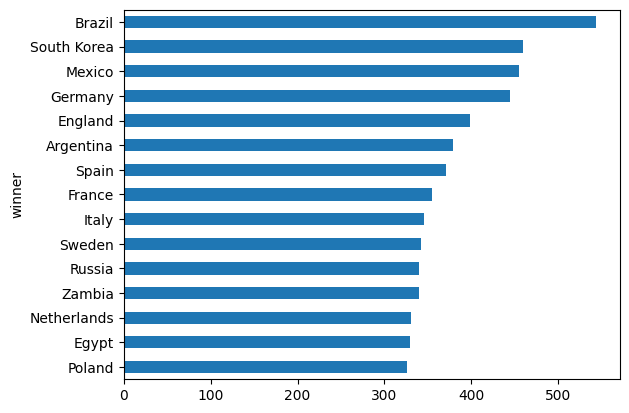

In [7]:
df60=results.copy()
df60['date']=df60['date'].dt.year
df60=df60.query("date >= 1960 & winner != 'Draw'")
df60['winner'].value_counts().sort_values(ascending=False).head(15).plot(kind='barh').invert_yaxis()

# 3. How many goals are scored in total in each minute of the game?


In [8]:
goals=pd.read_csv('/kaggle/input/international-football-results-from-1872-to-2017/goalscorers.csv')
goals['date']=pd.to_datetime(goals['date'])
goals['year']=goals['date'].dt.year
import plotly.express as px
fig = px.histogram(goals, x="minute",animation_frame="year",title='Number of goals each minute per year',color_discrete_sequence=['indianred'],range_y=[0,30],nbins=120)
fig.show()

# 4. Which 10 players have scored the most hat-tricks?

In [9]:
most3=goals.groupby(['date','scorer'])[['scorer']].agg('count').rename(columns={'scorer' : 'number_of_goals'}).sort_values('number_of_goals',ascending=False).reset_index()
most3=most3[most3['number_of_goals']>=3]
most3['scorer'].value_counts().head(10)

scorer
Cristiano Ronaldo        9
Robert Lewandowski       6
Damian Mori              5
Vaughan Coveny           5
Harry Kane               5
Just Fontaine            4
Yang Xu                  4
Gerd Müller              4
Carlos Ruiz              3
Karl-Heinz Rummenigge    3
Name: count, dtype: int64

# 5. What is the proportion of games won by each team at home and away? What is the difference between the proportions?


In [10]:
!pip install plotnine into cell

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... - error
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [1 lines of output]
      error in cell setup command: use_2to3 is invalid.
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [11]:
#Home Win
home_team_win = results[results.home_score > results.away_score]
home_team_win = pd.DataFrame(home_team_win.groupby(['home_team'])['home_team'].agg('count'))
home_team_win = home_team_win.rename(columns={'home_team':'home_matches_won'}).sort_values('home_matches_won',ascending=False).reset_index()

#Away Win
away_team_win = results[results.away_score > results.home_score]
away_team_win = pd.DataFrame(away_team_win.groupby(['away_team'])['away_team'].agg('count'))
away_team_win = away_team_win.rename(columns={'away_team':'away_matches_won'}).sort_values('away_matches_won',ascending=False).reset_index()

#Let's merge both
merged_df = pd.merge(home_team_win, away_team_win, left_on='home_team', right_on='away_team')
merged_df.drop(columns=['away_team'], inplace=True)
merged_df.rename(columns={'home_team': 'Team'}, inplace=True)


fig = px.bar(merged_df, 
             x='Team', 
             y=['home_matches_won', 'away_matches_won'], 
             barmode='stack',  
             labels={'value': 'Number of Matches Won'},
             title='Matches Won (Home vs. Away)')

# Customize hovermode to display tooltips only for the closest data point
fig.update_traces(hoverinfo='text')
fig.update_layout(hovermode='x')
fig.show()


# 6. How many games have been won by the home team? And by the away team?

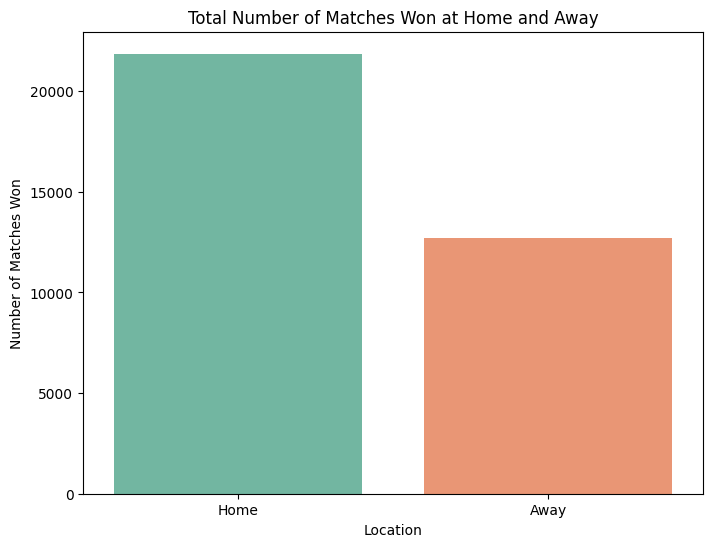

In [12]:
total_home_matches_won = merged_df['home_matches_won'].sum()
total_away_matches_won = merged_df['away_matches_won'].sum()

#creating a dataframe with these two info
total_matches_won = pd.DataFrame({
    'Location': ['Home', 'Away'],
    'Total Matches Won': [total_home_matches_won, total_away_matches_won]
})
# Plotting using Seaborn
plt.figure(figsize=(8, 6))
sns.barplot(x='Location', y='Total Matches Won', data=total_matches_won, palette='Set2')
plt.ylabel('Number of Matches Won')
plt.title('Total Number of Matches Won at Home and Away')
plt.show()


# 7. Focus on European football for Euro 2024
### What the UEFA Euro Tournament tells us?

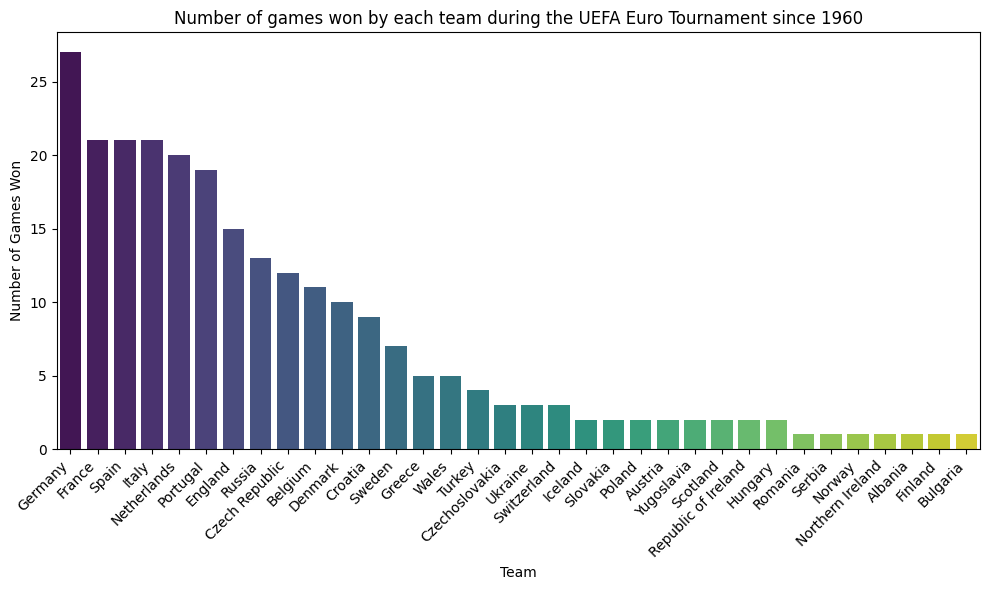

In [13]:
#Let's grab the tournament first
results['tournament'].unique()
euro = results[results["tournament"].isin(['UEFA Euro'])]
euro = euro[euro['winner'] != 'Draw']

# Combine 'home_team' and 'away_team' columns into a single column
teams = pd.concat([euro['home_team'], euro['away_team']])

# Count the number of wins for each team
team_wins = euro['winner'].value_counts()

# Plotting using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x=team_wins.index, y=team_wins.values, palette='viridis')
plt.xlabel('Team')
plt.ylabel('Number of Games Won')
plt.title('Number of games won by each team during the UEFA Euro Tournament since 1960')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_20/4232835426.py:8: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.



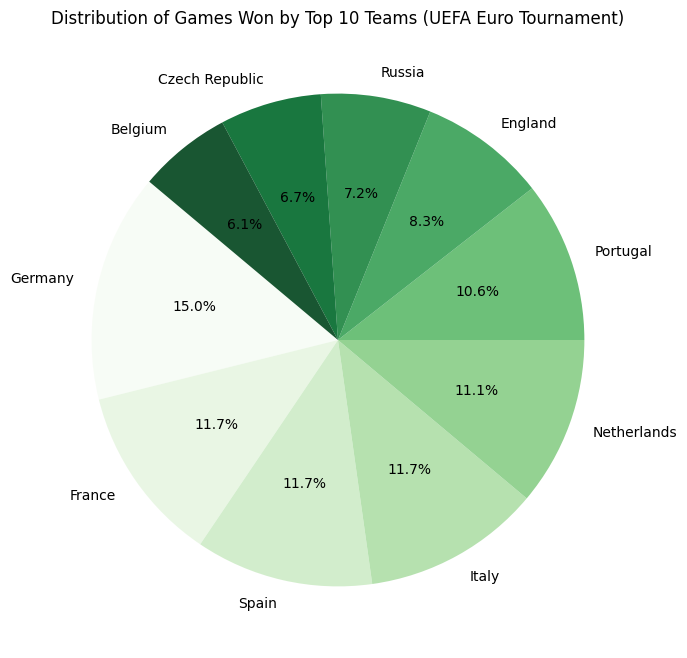

In [14]:
# Let's get the top 10 teams in a piechart
top_10_teams = team_wins.head(10)
# Define custom colors for each portion of the pie
from matplotlib.colors import ListedColormap
import numpy as np
# Define a custom colormap with different shades of green and reduced alpha (transparency)
num_colors = len(top_10_teams)
custom_cmap = plt.cm.get_cmap('Greens', num_colors)
custom_colors = custom_cmap(np.arange(num_colors))  # Get colors from the Greens colormap
custom_colors[:, -1] = 0.9  # Set alpha (transparency) to 0.7 for all colors

# Plotting a pie chart with different gradients of green (you know, like the football field)
plt.figure(figsize=(8, 8))
plt.pie(top_10_teams, labels=top_10_teams.index, autopct='%1.1f%%', startangle=140, colors=custom_colors)
plt.title('Distribution of Games Won by Top 10 Teams (UEFA Euro Tournament)')
plt.show()

## 7.1 Modern Era focus
The previous analysis is a little bit baised, because in the begining of Euro (1960), a few teams played, which means the biggest teams (France,Germany,etc.) played a lot more than some others. Let's analyse starting from 1992, where more teams where included.

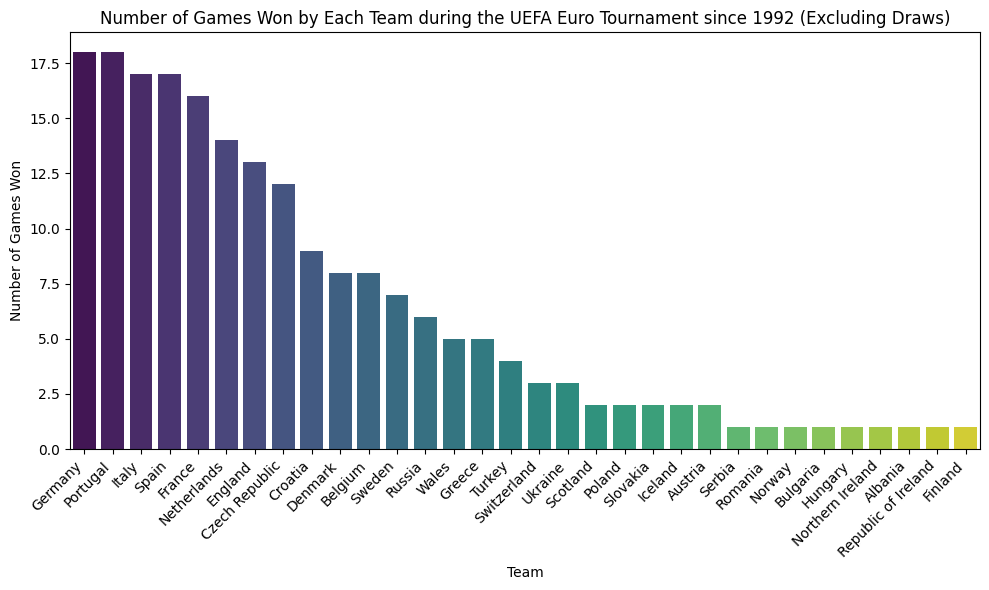

In [15]:
euro['year']=euro['date'].dt.year
euro_modern = euro[euro['year'] >= 1992]
team_wins = euro_modern['winner'].value_counts()
# Plotting using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x=team_wins.index, y=team_wins.values, palette='viridis')
plt.xlabel('Team')
plt.ylabel('Number of Games Won')
plt.title('Number of Games Won by Each Team during the UEFA Euro Tournament since 1992 (Excluding Draws)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Now we see that in the modern era, Portugal ranks at an higher position! Germany looks not so dominating as well.
We can also show this side to side:

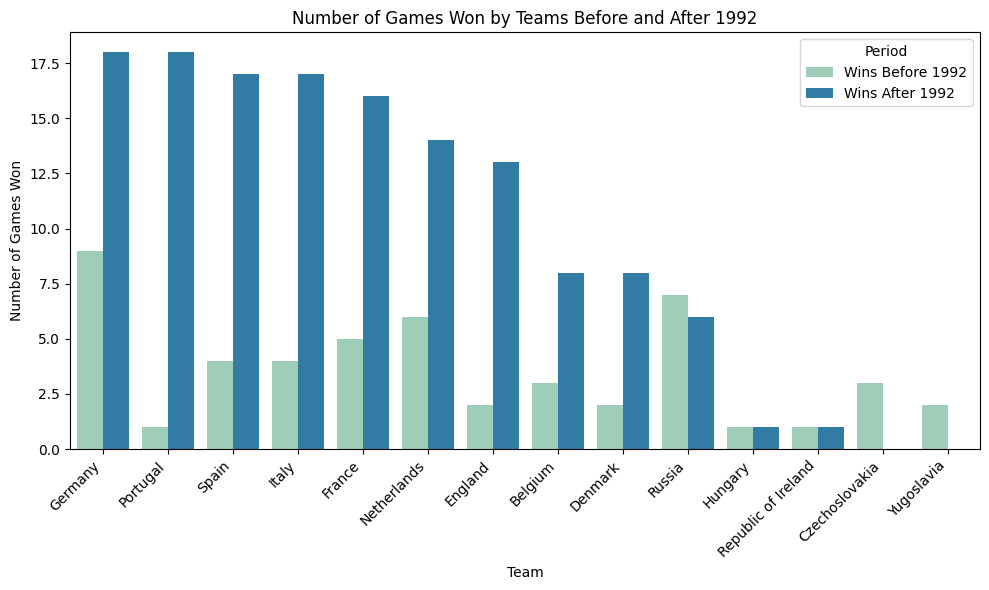

In [16]:
wins_before_1992 = euro[euro['year'] < 1992]['winner'].value_counts()
wins_after_1992 = euro[euro['year'] >= 1992]['winner'].value_counts()

# Create a new DataFrame with win counts for both periods
win_counts = pd.DataFrame({
    'Team': wins_before_1992.index,
    'Wins Before 1992': wins_before_1992.values,
    'Wins After 1992': wins_after_1992.reindex(wins_before_1992.index, fill_value=0).values
})

# Sort the DataFrame by 'Wins After 1992' column in descending order
win_counts_sorted = win_counts.sort_values(by='Wins After 1992', ascending=False)

# Melt the DataFrame for easy plotting
win_counts_melted = win_counts_sorted.melt(id_vars='Team', var_name='Period', value_name='Number of Wins')

# Plotting grouped bar plot using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Team', y='Number of Wins', hue='Period', data=win_counts_melted, palette='YlGnBu')
plt.xlabel('Team')
plt.ylabel('Number of Games Won')
plt.title('Number of Games Won by Teams Before and After 1992')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Let's include every games by these top european teams (not only during the UEFA Euro Tournament) since the previous Euro Tournament (2021) to find any trends.

In [17]:
#Selecting only the European Teams so we can make a list
euro['winner'].unique()

array(['Russia', 'Yugoslavia', 'Czechoslovakia', 'Spain', 'Hungary',
       'England', 'Italy', 'Germany', 'Belgium', 'Netherlands', 'France',
       'Denmark', 'Portugal', 'Republic of Ireland', 'Sweden', 'Scotland',
       'Croatia', 'Bulgaria', 'Czech Republic', 'Norway', 'Serbia',
       'Turkey', 'Romania', 'Greece', 'Switzerland', 'Ukraine', 'Wales',
       'Poland', 'Slovakia', 'Northern Ireland', 'Albania', 'Iceland',
       'Finland', 'Austria'], dtype=object)

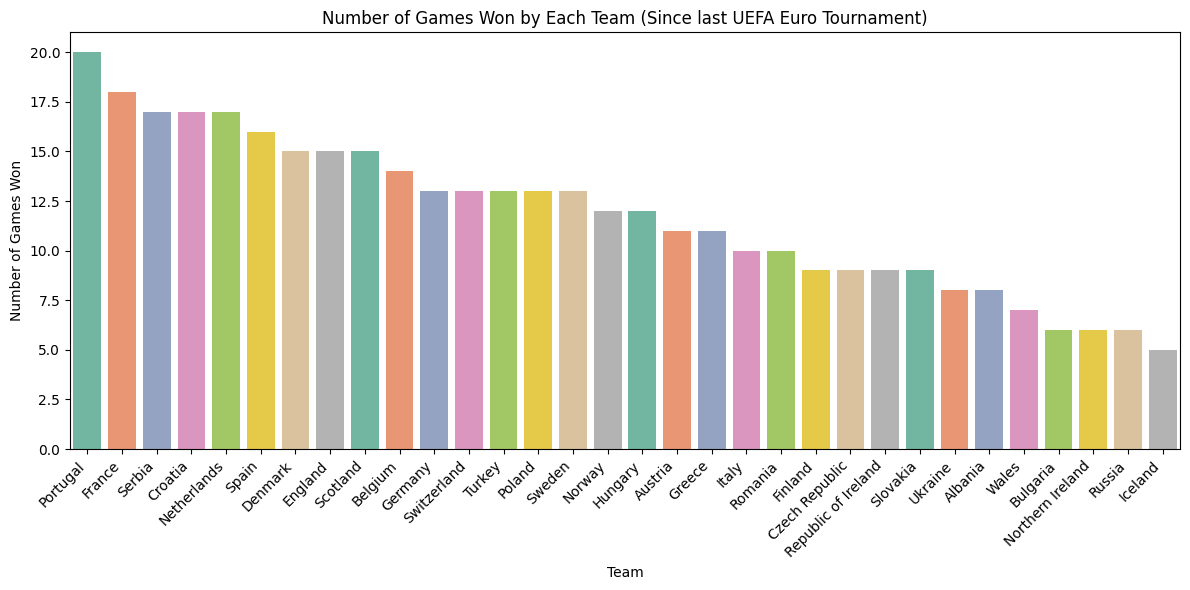

In [18]:
countries_to_filter = ['Russia', 'Yugoslavia', 'Czechoslovakia', 'Spain', 'Hungary', 'England', 'Italy', 'Germany', 'Belgium', 'Netherlands', 'France', 'Denmark', 'Portugal', 'Republic of Ireland', 'Sweden', 'Scotland', 'Croatia', 'Bulgaria', 'Czech Republic', 'Norway', 'Serbia', 'Turkey', 'Romania', 'Greece', 'Switzerland', 'Ukraine', 'Wales', 'Poland', 'Slovakia', 'Northern Ireland', 'Albania', 'Iceland', 'Finland', 'Austria']
# Filtering rows based on the list of countries and from the date of the  last final
results_filtered = results[results['winner'].isin(countries_to_filter) & (results['date'] > '2021-07-11T00:00:00.000')]

# Counting games won by each team
team_wins_ = results_filtered['winner'].value_counts()

# Plotting the number of games won by each team across the years
plt.figure(figsize=(12, 6))
sns.barplot(x=team_wins_.index, y=team_wins_.values, palette='Set2')
plt.xlabel('Team')
plt.ylabel('Number of Games Won')
plt.title('Number of Games Won by Each Team (Since last UEFA Euro Tournament)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Since the last tournament, Serbia and Crotia are getting better, and Germany is not the favourite anymore. Portugal seems to to be the top team.